# Phase 5 — Deep Learning for RUL Prediction

**Dataset:** NASA CMAPSS FD001  
**Architectures:** LSTM · GRU · BiLSTM (1 layer, hidden=64)  
**Loss:** Asymmetric MSE — penalises over-prediction in the low-RUL danger zone  
**Goal:** Improve on Phase 4 XGBoost baseline (RMSE=14.56, low-RUL bias=+2.54)

Stage 1 of 2 — experimentation notebook. Stage 2 productionises the winner into `sequence_trainer.py`.

In [1]:
# --- Section 0: Setup ---
import os
import sys
import copy
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROJECT_ROOT = Path("..").resolve()
os.chdir(PROJECT_ROOT)          # ensure relative paths (raw data, configs) resolve correctly
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rul_prediction.config.configuration import load_config
from rul_prediction.components.data_ingestion import DataIngestion

config = load_config(PROJECT_ROOT / "configs" / "config.yaml")

PROCESSED_DIR    = PROJECT_ROOT / config["paths"]["processed_data_dir"]
SAVED_MODELS_DIR = PROJECT_ROOT / config["paths"]["saved_models_dir"]
REPORTS_DIR      = PROJECT_ROOT / "reports"
FIGURES_DIR      = REPORTS_DIR / "figures"
REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SUBSET   = config["dataset"]["active_subset"]
SEED     = config["seed"]
HIDDEN   = config["model"]["hidden_size"]
N_LAYERS = config["model"]["num_layers"]
DROPOUT  = config["model"]["dropout"]
PATIENCE = config["model"]["early_stopping_patience"]
TAU      = config["model"]["rul_threshold"]
ALPHA    = config["model"]["loss_alpha"]
LR       = config["training"]["learning_rate"]
BATCH    = config["training"]["batch_size"]
EPOCHS   = config["training"]["num_epochs"]

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"torch {torch.__version__}  |  seed={SEED}  |  subset={SUBSET}")
print(f"Architecture: hidden={HIDDEN}  layers={N_LAYERS}  dropout={DROPOUT}")
print(f"Loss: alpha={ALPHA}  tau={TAU}  |  Training: lr={LR}  batch={BATCH}  max_epochs={EPOCHS}")

[2026-07-05 01:41:14,235] INFO     rul_prediction.config.configuration - Loading config from C:\Users\Satyam Mishra\OneDrive\Desktop\RUL aircraft engine AI project\configs\config.yaml


torch 2.12.1+cpu  |  seed=42  |  subset=FD001
Architecture: hidden=64  layers=1  dropout=0.2
Loss: alpha=2.0  tau=30.0  |  Training: lr=0.001  batch=64  max_epochs=200


## 1. Load Sequence Data

Input shape: `(n_windows, 30, 17)` — 30-cycle sliding windows over 17 informative sensors.  
Already produced by the Preprocessor (Phase 3); no reprocessing needed.

In [2]:
X_train = np.load(PROCESSED_DIR / "train_X_seq.npy")
y_train = np.load(PROCESSED_DIR / "train_y.npy")
X_val   = np.load(PROCESSED_DIR / "val_X_seq.npy")
y_val   = np.load(PROCESSED_DIR / "val_y.npy")
train_engine_ids = np.load(PROCESSED_DIR / "train_engine_ids.npy")
val_engine_ids   = np.load(PROCESSED_DIR / "val_engine_ids.npy")

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"y_train range: [{y_train.min():.0f}, {y_train.max():.0f}]  (capped at {config['dataset']['rul_cap']})")
print(f"Train engines: {len(np.unique(train_engine_ids))}   Val engines: {len(np.unique(val_engine_ids))}")

X_train : (14241, 30, 17)   y_train : (14241,)
X_val   : (3490, 30, 17)     y_val   : (3490,)
y_train range: [0, 125]  (capped at 125)
Train engines: 80   Val engines: 20


## 2. Load Test Ground-Truth RUL

`RUL_FD001.txt` has **one RUL per engine** (the true value at the last recorded cycle).  
The test `X_seq` has multiple windows per engine, so we keep only the **last window** per engine — this aligns correctly with the ground-truth file.

In [3]:
X_test_seq      = np.load(PROCESSED_DIR / "test_X_seq.npy")
engine_ids_test = np.load(PROCESSED_DIR / "test_engine_ids.npy")
y_test          = DataIngestion(subset=SUBSET).load_test_rul()["RUL"].values  # uncapped

unique_test_engines = np.unique(engine_ids_test)
last_idx = [int(np.where(engine_ids_test == eid)[0][-1]) for eid in unique_test_engines]
X_test = X_test_seq[last_idx]

assert len(X_test) == len(y_test), f"Alignment error: {len(X_test)} windows vs {len(y_test)} RUL values"
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"y_test range: [{y_test.min():.0f}, {y_test.max():.0f}]  (uncapped — evaluation ground truth)")

[2026-07-05 01:41:14,273] INFO     rul_prediction.components.data_ingestion - Reading test RUL file: data\raw\FD001\RUL_FD001.txt


X_test  : (100, 30, 17)    y_test  : (100,)
y_test range: [7, 145]  (uncapped — evaluation ground truth)


## 3. Asymmetric Loss Function

Standard MSE penalises over- and under-prediction symmetrically. For aircraft health monitoring,
**predicting more RUL than the engine has** (optimistic error) is the dangerous case — it can delay
maintenance beyond safe limits.

Phase 4 XGBoost baseline had a mean low-RUL bias of **+2.54 cycles** (positive = optimistic).

**Proposed: Low-RUL Asymmetric MSE**

$$
w = \alpha \quad \text{if } (\hat{y} > y) \text{ AND } (y < \tau) \quad \text{[dangerous zone]}
$$
$$
w = 1 \quad \text{otherwise}
$$
$$
\mathcal{L} = \text{mean}\bigl(w \cdot (\hat{y} - y)^2\bigr)
$$

With $\tau = 30$ and $\alpha = 2.0$: over-predictions near failure cost twice as much.

In [4]:
def asymmetric_rul_loss(y_pred, y_true, rul_threshold=30.0, alpha=2.0):
    """Asymmetric MSE: penalises over-prediction when y_true < rul_threshold."""
    residual = y_pred - y_true
    weight = torch.where(
        (residual > 0) & (y_true < rul_threshold),
        torch.full_like(residual, alpha),
        torch.ones_like(residual),
    )
    return (weight * residual**2).mean()


# Unit tests
def _mse(yp, yt):
    return ((torch.tensor([yp]) - torch.tensor([yt]))**2).mean().item()

cases = [
    # (y_pred, y_true, expected_ratio, description)
    (15.0, 10.0, ALPHA, "over-pred in danger zone  -> alpha penalty"),
    ( 5.0, 10.0,   1.0, "under-pred in danger zone -> standard MSE"),
    (90.0, 80.0,   1.0, "over-pred in safe zone    -> standard MSE"),
]
for yp, yt, expected_ratio, desc in cases:
    yp_t, yt_t = torch.tensor([yp]), torch.tensor([yt])
    asym = asymmetric_rul_loss(yp_t, yt_t, TAU, ALPHA).item()
    mse  = _mse(yp, yt)
    ratio = asym / mse
    status = "PASS" if abs(ratio - expected_ratio) < 1e-4 else "FAIL"
    print(f"[{status}] {desc}  asym={asym:.1f}  mse={mse:.1f}  ratio={ratio:.1f}x")

[PASS] over-pred in danger zone  -> alpha penalty  asym=50.0  mse=25.0  ratio=2.0x
[PASS] under-pred in danger zone -> standard MSE  asym=25.0  mse=25.0  ratio=1.0x
[PASS] over-pred in safe zone    -> standard MSE  asym=100.0  mse=100.0  ratio=1.0x


## 4. Model Architecture

### Why small networks for FD001?

FD001 has 100 engines; 80 in training. After sliding-window expansion there are ~14 k windows,
but adjacent windows share 29/30 time steps — effectively ~80 independent samples.
Large networks (hidden ≥ 256, 2+ layers) overfit reliably on this dataset
(Zheng et al. 2017, Li et al. 2018). Published CMAPSS benchmarks use 1 layer, hidden 64–128.

| Model | Layers | Hidden | Approx params |
|---|---|---|---|
| LSTM   | 1 | 64 | ~35 k |
| GRU    | 1 | 64 | ~26 k |
| BiLSTM | 1 | 64/dir | ~67 k |

In [5]:
class RULSequenceModel(nn.Module):
    """Single-file RNN for RUL regression. LSTM, GRU, or BiLSTM via model_type."""

    def __init__(self, input_size, hidden_size, num_layers, model_type, dropout=0.2):
        super().__init__()
        assert model_type in ("lstm", "gru", "bilstm"), f"Unknown model_type: {model_type}"
        self.model_type = model_type
        bidirectional = (model_type == "bilstm")
        rnn_cls       = nn.LSTM if model_type in ("lstm", "bilstm") else nn.GRU
        rnn_dropout   = dropout if num_layers > 1 else 0.0
        self.rnn = rnn_cls(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=rnn_dropout, bidirectional=bidirectional,
        )
        self.drop = nn.Dropout(dropout)
        fc_in = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        out, _ = self.rnn(x)         # (batch, seq_len, hidden * dirs)
        last   = self.drop(out[:, -1, :])  # last time step
        return self.fc(last).squeeze(-1)   # (batch,)


def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


INPUT_SIZE = X_train.shape[2]  # 17 sensors
for mtype in ("lstm", "gru", "bilstm"):
    m = RULSequenceModel(INPUT_SIZE, HIDDEN, N_LAYERS, mtype, DROPOUT)
    print(f"{mtype:8s}: {n_params(m):7,d} trainable parameters")

lstm    :  21,313 trainable parameters
gru     :  16,001 trainable parameters
bilstm  :  42,625 trainable parameters


## 5. Training Infrastructure

In [6]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def _train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    losses = []
    for X_b, y_b in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def _eval_epoch(model, loader, loss_fn):
    model.eval()
    losses = []
    with torch.no_grad():
        for X_b, y_b in loader:
            losses.append(loss_fn(model(X_b), y_b).item())
    return float(np.mean(losses))


def predict_np(model, X_np):
    model.eval()
    with torch.no_grad():
        return model(torch.from_numpy(X_np).float()).numpy()


def compute_metrics(y_true, y_pred, low_rul_threshold=30):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = y_true < low_rul_threshold
    if mask.sum() > 0:
        low_rmse = float(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])))
        low_bias = float((y_pred[mask] - y_true[mask]).mean())
    else:
        low_rmse = low_bias = float("nan")
    return {"rmse": rmse, "mae": mae, "r2": r2,
            "low_rul_rmse": low_rmse, "low_rul_bias": low_bias}


def train_model(model_type, X_tr, y_tr, X_v, y_v):
    """Train one architecture. Returns (model, history_dict, elapsed_s)."""
    torch.manual_seed(SEED)
    model     = RULSequenceModel(INPUT_SIZE, HIDDEN, N_LAYERS, model_type, DROPOUT)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=5, factor=0.5
    )
    loss_fn = lambda yp, yt: asymmetric_rul_loss(yp, yt, TAU, ALPHA)

    train_loader = DataLoader(RULDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(RULDataset(X_v,  y_v),  batch_size=BATCH, shuffle=False)

    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, no_improve = float("inf"), {}, 0

    t0 = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        tl = _train_epoch(model, train_loader, optimizer, loss_fn)
        vl = _eval_epoch(model, val_loader,   loss_fn)
        scheduler.step(vl)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)

        if vl < best_val:
            best_val   = vl
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            print(f"  [{model_type}] Early stopping at epoch {epoch}  best_val={best_val:.4f}")
            break

    model.load_state_dict(best_state)
    elapsed = time.perf_counter() - t0
    print(f"  [{model_type}] Done: {epoch} epochs  {elapsed:.1f}s  best_val={best_val:.4f}")
    return model, history, elapsed


def plot_learning_curve(history, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["train_loss"], label="Train (asymmetric MSE)")
    ax.plot(history["val_loss"],   label="Val  (asymmetric MSE)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


print("Training infrastructure ready.")

Training infrastructure ready.


## 6. LSTM

Training LSTM...


  [lstm] Early stopping at epoch 46  best_val=137.1127
  [lstm] Done: 46 epochs  78.7s  best_val=137.1127


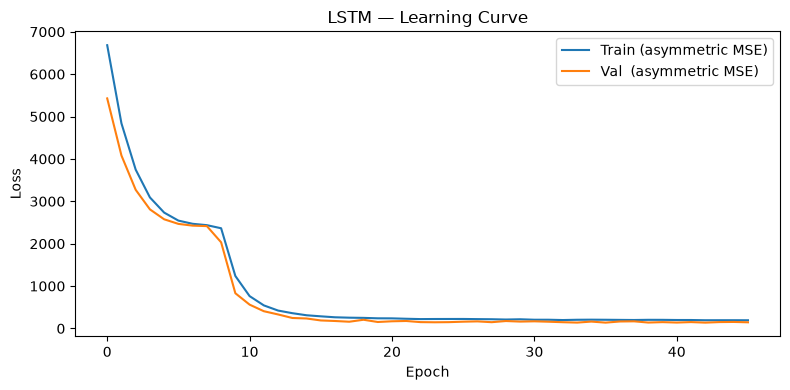

LSTM test metrics:

 {'rmse': 15.0368, 'mae': 11.4316, 'r2': 0.8691, 'low_rul_rmse': 3.8631, 'low_rul_bias': -0.427, 'model': 'LSTM', 'params': 21313, 'training_s': 78.7}


In [7]:
print("Training LSTM...")
lstm_model, lstm_hist, lstm_time = train_model("lstm", X_train, y_train, X_val, y_val)
plot_learning_curve(lstm_hist, "LSTM — Learning Curve")

lstm_preds   = predict_np(lstm_model, X_test)
lstm_metrics = compute_metrics(y_test, lstm_preds)
lstm_metrics.update({"model": "LSTM", "params": n_params(lstm_model), "training_s": round(lstm_time, 1)})
print("LSTM test metrics:", {k: round(v, 4) if isinstance(v, float) else v for k, v in lstm_metrics.items()})

## 7. GRU

Training GRU...


  [gru] Early stopping at epoch 42  best_val=148.3157
  [gru] Done: 42 epochs  132.8s  best_val=148.3157


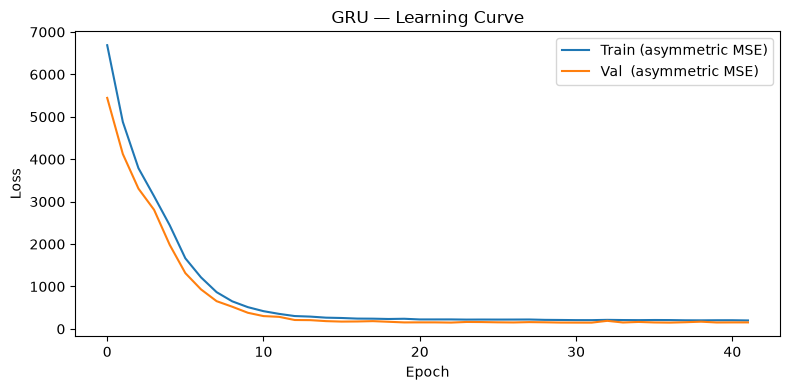

GRU test metrics: {'rmse': 15.2188, 'mae': 11.5441, 'r2': 0.8659, 'low_rul_rmse': 3.7332, 'low_rul_bias': -1.2512, 'model': 'GRU', 'params': 16001, 'training_s': 132.8}


In [8]:
print("Training GRU...")
gru_model, gru_hist, gru_time = train_model("gru", X_train, y_train, X_val, y_val)
plot_learning_curve(gru_hist, "GRU — Learning Curve")

gru_preds   = predict_np(gru_model, X_test)
gru_metrics = compute_metrics(y_test, gru_preds)
gru_metrics.update({"model": "GRU", "params": n_params(gru_model), "training_s": round(gru_time, 1)})
print("GRU test metrics:", {k: round(v, 4) if isinstance(v, float) else v for k, v in gru_metrics.items()})

## 8. BiLSTM

Training BiLSTM...


  [bilstm] Early stopping at epoch 44  best_val=141.4032
  [bilstm] Done: 44 epochs  151.9s  best_val=141.4032


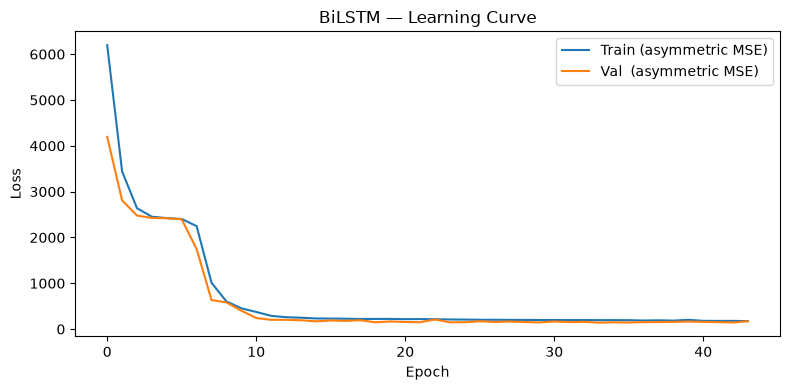

BiLSTM test metrics: {'rmse': 15.0167, 'mae': 11.4799, 'r2': 0.8694, 'low_rul_rmse': 3.9437, 'low_rul_bias': 1.4199, 'model': 'BiLSTM', 'params': 42625, 'training_s': 151.9}


In [9]:
print("Training BiLSTM...")
bilstm_model, bilstm_hist, bilstm_time = train_model("bilstm", X_train, y_train, X_val, y_val)
plot_learning_curve(bilstm_hist, "BiLSTM — Learning Curve")

bilstm_preds   = predict_np(bilstm_model, X_test)
bilstm_metrics = compute_metrics(y_test, bilstm_preds)
bilstm_metrics.update({"model": "BiLSTM", "params": n_params(bilstm_model), "training_s": round(bilstm_time, 1)})
print("BiLSTM test metrics:", {k: round(v, 4) if isinstance(v, float) else v for k, v in bilstm_metrics.items()})

## 9. Comparison Table

Phase 4 XGBoost baseline is included as a reference row (`*` = placeholder params, non-Optuna-tuned).

In [10]:
xgb_baseline = {
    "model": "XGBoost*",
    "rmse": 14.56, "mae": 11.42, "r2": 0.877,
    "low_rul_rmse": 6.21, "low_rul_bias": 2.54,
    "params": None, "training_s": None,
}

all_results = [xgb_baseline, lstm_metrics, gru_metrics, bilstm_metrics]
df = pd.DataFrame(all_results)

display_cols = ["model", "rmse", "mae", "r2", "low_rul_rmse", "low_rul_bias", "params", "training_s"]
df_disp = df[display_cols].copy()
for col in ["rmse", "mae", "r2", "low_rul_rmse", "low_rul_bias"]:
    df_disp[col] = df_disp[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")

print(df_disp.to_string(index=False))

out_path = REPORTS_DIR / "dl_comparison.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved to {out_path}")

   model    rmse     mae     r2 low_rul_rmse low_rul_bias  params  training_s
XGBoost* 14.5600 11.4200 0.8770       6.2100       2.5400     NaN         NaN
    LSTM 15.0368 11.4316 0.8691       3.8631      -0.4270 21313.0        78.7
     GRU 15.2188 11.5441 0.8659       3.7332      -1.2512 16001.0       132.8
  BiLSTM 15.0167 11.4799 0.8694       3.9437       1.4199 42625.0       151.9

Saved to C:\Users\Satyam Mishra\OneDrive\Desktop\RUL aircraft engine AI project\reports\dl_comparison.csv


## 10. Error Analysis — Best DL Model

Scatter plot (predicted vs true) and residuals coloured by RUL zone.  
Key question: did the asymmetric loss reduce the optimistic bias at low RUL?

Best DL model: BiLSTM  RMSE=15.0167


Saved -> C:\Users\Satyam Mishra\OneDrive\Desktop\RUL aircraft engine AI project\reports\figures\dl_residuals_bilstm.png


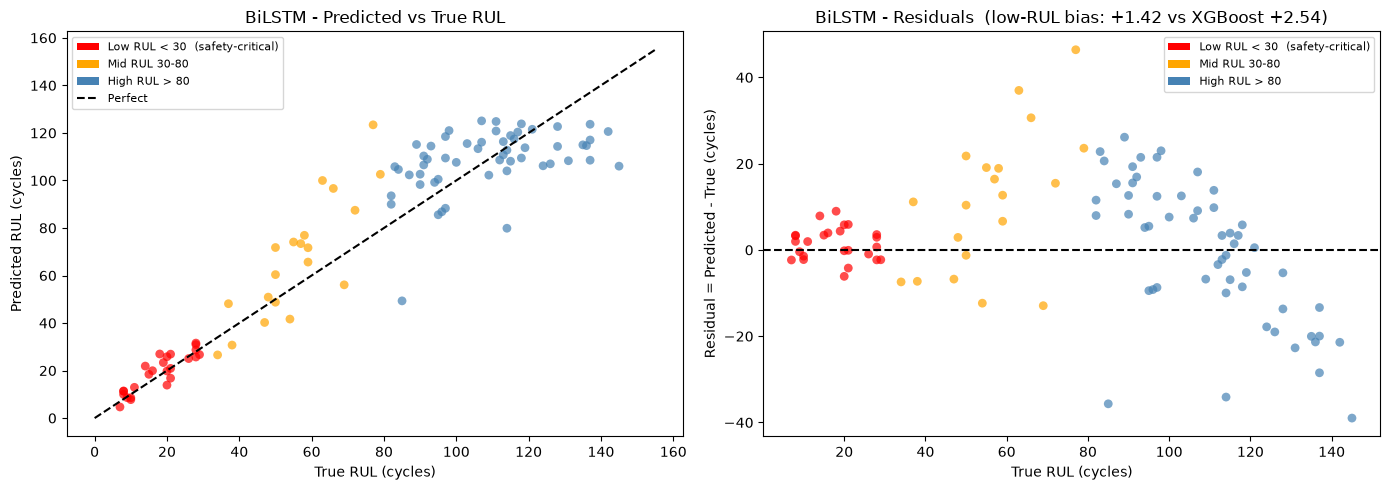

In [11]:
# Pick best DL model by test RMSE
dl_candidates = [
    (lstm_metrics["rmse"],   lstm_model,   lstm_preds,   lstm_metrics),
    (gru_metrics["rmse"],    gru_model,    gru_preds,    gru_metrics),
    (bilstm_metrics["rmse"], bilstm_model, bilstm_preds, bilstm_metrics),
]
_, best_model, best_preds, best_metrics = min(dl_candidates, key=lambda x: x[0])
print(f"Best DL model: {best_metrics['model']}  RMSE={best_metrics['rmse']:.4f}")

zone_colors = ["red" if r < 30 else ("orange" if r < 80 else "steelblue") for r in y_test]
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor="red",       label="Low RUL < 30  (safety-critical)"),
    Patch(facecolor="orange",    label="Mid RUL 30-80"),
    Patch(facecolor="steelblue", label="High RUL > 80"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs true
ax = axes[0]
ax.scatter(y_test, best_preds, c=zone_colors, alpha=0.7, s=40, edgecolors="none")
_lim = max(float(y_test.max()), float(best_preds.max())) + 10
ax.plot([0, _lim], [0, _lim], "k--", lw=1.5, label="Perfect")
ax.set_xlabel("True RUL (cycles)")
ax.set_ylabel("Predicted RUL (cycles)")
ax.set_title(f"{best_metrics['model']} - Predicted vs True RUL")
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],color='k',linestyle='--',label='Perfect')], fontsize=8)

# Residuals: pred - true
residuals = best_preds - y_test
ax = axes[1]
ax.scatter(y_test, residuals, c=zone_colors, alpha=0.7, s=40, edgecolors="none")
ax.axhline(0, color="black", linestyle="--", lw=1.5)
ax.set_xlabel("True RUL (cycles)")
ax.set_ylabel("Residual = Predicted - True (cycles)")
ax.set_title(
    f"{best_metrics['model']} - Residuals  "
    f"(low-RUL bias: {best_metrics['low_rul_bias']:+.2f} vs XGBoost +2.54)"
)
ax.legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
fig_path = FIGURES_DIR / f"dl_residuals_{best_metrics['model'].lower()}.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {fig_path}")
plt.show()

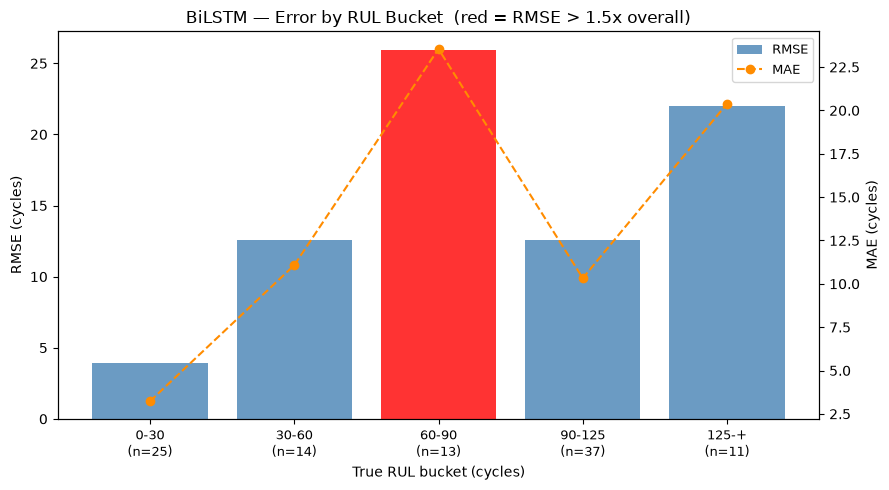

In [12]:
# Error by RUL bucket
BUCKET_EDGES = [0, 30, 60, 90, 125, 9999]

b_labels, b_rmse, b_mae, b_n = [], [], [], []
for lo, hi in zip(BUCKET_EDGES[:-1], BUCKET_EDGES[1:]):
    mask = (y_test >= lo) & (y_test < hi)
    n = int(mask.sum())
    hi_str = str(hi) if hi < 9999 else "+"
    b_labels.append(f"{lo}-{hi_str}")
    b_n.append(n)
    if n > 0:
        b_rmse.append(float(np.sqrt(mean_squared_error(y_test[mask], best_preds[mask]))))
        b_mae.append(float(mean_absolute_error(y_test[mask], best_preds[mask])))
    else:
        b_rmse.append(0.0)
        b_mae.append(0.0)

overall_rmse = best_metrics["rmse"]
bar_colors = ["red" if (n > 0 and r > 1.5 * overall_rmse) else "steelblue"
              for r, n in zip(b_rmse, b_n)]

x = np.arange(len(b_labels))
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(x, b_rmse, color=bar_colors, alpha=0.8, label="RMSE")
ax1.set_xlabel("True RUL bucket (cycles)")
ax1.set_ylabel("RMSE (cycles)")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{lbl}\n(n={n})" for lbl, n in zip(b_labels, b_n)], fontsize=9)
ax1.set_title(f"{best_metrics['model']} — Error by RUL Bucket  (red = RMSE > 1.5x overall)")

ax2 = ax1.twinx()
ax2.plot(x, b_mae, "o--", color="darkorange", lw=1.5, label="MAE")
ax2.set_ylabel("MAE (cycles)")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9)
plt.tight_layout()
plt.show()

## 11. Key Findings

In [13]:
dl_df = df[df["model"] != "XGBoost*"].copy()
winner_row = dl_df.loc[dl_df["rmse"].idxmin()]
winner_type = winner_row["model"].lower()

xgb_rmse = xgb_baseline["rmse"]
xgb_bias = xgb_baseline["low_rul_bias"]

print("=" * 60)
print(f"  Winner : {winner_row['model']}")
print(f"  RMSE   : {winner_row['rmse']:.4f}  (XGBoost: {xgb_rmse})")
print(f"  MAE    : {winner_row['mae']:.4f}")
print(f"  R2     : {winner_row['r2']:.4f}")
print(f"  low-RUL RMSE : {winner_row['low_rul_rmse']:.4f}")
print(f"  low-RUL bias : {winner_row['low_rul_bias']:+.4f}  (XGBoost: +{xgb_bias}  — positive = optimistic = dangerous)")
print("=" * 60)
print()
print("Next step: update configs/config.yaml")
print(f"  model.type: '{winner_type}'")
print()
print("Then run Stage 2 smoke test:")
print("  uv run python -m rul_prediction.components.sequence_trainer")

  Winner : BiLSTM
  RMSE   : 15.0167  (XGBoost: 14.56)
  MAE    : 11.4799
  R2     : 0.8694
  low-RUL RMSE : 3.9437
  low-RUL bias : +1.4199  (XGBoost: +2.54  — positive = optimistic = dangerous)

Next step: update configs/config.yaml
  model.type: 'bilstm'

Then run Stage 2 smoke test:
  uv run python -m rul_prediction.components.sequence_trainer
